# Results analysis: workflow (3pct / 10pct)

Focused analysis for **bm25**, **dense**, **hybrid**, and **rerank** outputs. Supports two dataset sizes:

- **3pct (small):** `output/workflow_local_3pct_hpc_bge` — train: `example/training14b_3pct_sample.json`, test: `example/13b_golden_50q_sample.json`
- **10pct (big):** `output/workflow_local_10pct_hpc_bge` — train: `example/training14b_10pct_sample.json`, test: 4 batches in `bioasq_data/Task13BGoldenEnriched` (13B1–13B4)

**Goals:**
1. **Ceiling (Hybrid @ K=2000):** Does Hybrid contain the gold by K=2000? Table of queries with recall@2000 = 0.
2. **n_rel vs low recall:** Is `n_rel` driving the low-recall tail? Scatter (n_rel vs R@200) + Spearman; bin-and-plot median ± IQR.
3. **Compare 3pct vs 10pct** when both are loaded (tables and plots by dataset).

## Setup and paths

In [37]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

base_dir = Path(".").resolve()
if not (base_dir / "example").exists():
    base_dir = base_dir.parent  # run from notebooks/
    assert (base_dir / "example").exists(), "Run from repo root or notebooks/"

# --- Dataset configs: 3pct (small) vs 10pct (big) ---
DATASET_CONFIG = {
    "3pct": {
        "workflow_dir": base_dir / "output" / "workflow_local_3pct_hpc_bge",
        "splits": ["training14b_3pct_sample", "13b_golden_50q_sample"],
        "qrels_paths": {
            "training14b_3pct_sample": base_dir / "example" / "training14b_3pct_sample.json",
            "13b_golden_50q_sample": base_dir / "example" / "13b_golden_50q_sample.json",
        },
        "label": "3pct (small)",
    },
    "10pct": {
        "workflow_dir": base_dir / "output" / "workflow_local_10pct_hpc_bge",
        "splits": [
            "training14b_10pct_sample",
            "13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden",
        ],
        "qrels_paths": {
            "training14b_10pct_sample": base_dir / "example" / "training14b_10pct_sample.json",
            "13B1_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
            "13B2_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
            "13B3_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
            "13B4_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
        },
        "label": "10pct (big)",
    },
}

# Select which set(s) to load: one of ["3pct"], ["10pct"], or ["3pct", "10pct"] for both
SELECTED_DATASETS = ["3pct", "10pct"]

for name in SELECTED_DATASETS:
    assert name in DATASET_CONFIG, f"Unknown dataset: {name}"
    cfg = DATASET_CONFIG[name]
    assert cfg["workflow_dir"].exists(), f"Missing {cfg['workflow_dir']}"
    for s, p in cfg["qrels_paths"].items():
        assert p.exists(), f"Missing {p} for {name}/{s}: {p}"

# (dataset, split) groups: one panel per group — never merge across datasets or across splits
ANALYSIS_GROUPS = [
    (ds, sp) for ds in SELECTED_DATASETS for sp in DATASET_CONFIG[ds]["splits"]
]

# For convenience when a single dataset is selected
splits = DATASET_CONFIG[SELECTED_DATASETS[0]]["splits"] if len(SELECTED_DATASETS) == 1 else None
workflow_dir = DATASET_CONFIG[SELECTED_DATASETS[0]]["workflow_dir"] if len(SELECTED_DATASETS) == 1 else None

print("Selected datasets:", SELECTED_DATASETS)
print("Analysis groups (dataset / split):", ANALYSIS_GROUPS)
for name in SELECTED_DATASETS:
    cfg = DATASET_CONFIG[name]
    print(f"  {name}: {cfg['workflow_dir'].name}, splits = {cfg['splits']}")

Selected datasets: ['3pct', '10pct']
Analysis groups (dataset / split): [('3pct', 'training14b_3pct_sample'), ('3pct', '13b_golden_50q_sample'), ('10pct', 'training14b_10pct_sample'), ('10pct', '13B1_golden'), ('10pct', '13B2_golden'), ('10pct', '13B3_golden'), ('10pct', '13B4_golden')]
  3pct: workflow_local_3pct_hpc_bge, splits = ['training14b_3pct_sample', '13b_golden_50q_sample']
  10pct: workflow_local_10pct_hpc_bge, splits = ['training14b_10pct_sample', '13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden']


## Load qrels, question text, and n_rel

In [38]:
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def load_qrels(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    out = {}
    for q in data.get("questions", []):
        qid = q.get("id")
        if not qid:
            continue
        qid = str(qid)
        docs = q.get("documents", [])
        pmids = {str(_extract_pmid(d)) for d in docs if _extract_pmid(d)}
        out[qid] = pmids
    return out


def load_question_text_and_n_rel(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    text_by_qid = {}
    n_rel_by_qid = {}
    for q in data.get("questions", []):
        qid = q.get("id")
        if not qid:
            continue
        qid = str(qid)
        text_by_qid[qid] = (q.get("body") or "").strip()
        docs = q.get("documents", [])
        n_rel_by_qid[qid] = len([d for d in docs if _extract_pmid(d)])
    return text_by_qid, n_rel_by_qid


# Load per selected dataset (keyed by dataset name)
qrels_by_dataset = {}
question_text_by_dataset = {}
n_rel_by_dataset = {}
for name in SELECTED_DATASETS:
    qrels_paths = DATASET_CONFIG[name]["qrels_paths"]
    qrels_by_dataset[name] = {s: load_qrels(p) for s, p in qrels_paths.items()}
    question_text_by_dataset[name] = {}
    n_rel_by_dataset[name] = {}
    for s, p in qrels_paths.items():
        txt, nrel = load_question_text_and_n_rel(p)
        question_text_by_dataset[name][s] = txt
        n_rel_by_dataset[name][s] = nrel

# Backward compatibility: when only one dataset, expose as qrels_by_split etc.
if len(SELECTED_DATASETS) == 1:
    name = SELECTED_DATASETS[0]
    qrels_by_split = qrels_by_dataset[name]
    question_text_by_split = question_text_by_dataset[name]
    n_rel_by_split = n_rel_by_dataset[name]

for name in SELECTED_DATASETS:
    q = qrels_by_dataset[name]
    print(f"{name} qrels: ", {s: len(qq) for s, qq in q.items()})

3pct qrels:  {'training14b_3pct_sample': 192, '13b_golden_50q_sample': 50}
10pct qrels:  {'training14b_10pct_sample': 923, '13B1_golden': 85, '13B2_golden': 85, '13B3_golden': 85, '13B4_golden': 85}


## Compute Hybrid per-query recall (from run TSVs)

In [39]:
def load_run(path: Path):
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    rank_col = cols.get("rank")
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def recall_at_k(docs: list, rels: set, k: int) -> float:
    if not rels:
        return np.nan
    top = docs[:k]
    hit = len(set(top) & rels)
    return hit / len(rels)


def ap_at_k(docs: list, rels: set, k: int = 10) -> float:
    """Average precision at k (per-query AP@10)."""
    if not rels:
        return np.nan
    top = docs[:k]
    hits = 0
    prec_sum = 0.0
    for i, doc in enumerate(top, start=1):
        if doc in rels:
            hits += 1
            prec_sum += hits / i
    if hits == 0:
        return 0.0
    return prec_sum / min(len(rels), k)


def compute_hybrid_per_query_recall(hybrid_runs_dir: Path, qrels_by_split: dict, k_values=(200, 2000)):
    run_template = "best_rrf_{split}_top5000.tsv"
    rows = []
    for split, qrels in qrels_by_split.items():
        run_path = hybrid_runs_dir / run_template.format(split=split)
        if not run_path.exists():
            print(f"Missing: {run_path}")
            continue
        run_df = load_run(run_path)
        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels.get(qid, set())
            if not rels:
                continue
            docs = group[doc_col].tolist()
            row = {"split": split, "qid": qid, "AP@10": ap_at_k(docs, rels, 10)}
            for k in k_values:
                row[f"R@{k}"] = recall_at_k(docs, rels, k)
            rows.append(row)
    return pd.DataFrame(rows)


# Compute Hybrid per-query recall for each selected dataset; concat with dataset column
hybrid_dfs = []
for name in SELECTED_DATASETS:
    cfg = DATASET_CONFIG[name]
    hybrid_runs_dir = cfg["workflow_dir"] / "hybrid" / "runs"
    df_one = compute_hybrid_per_query_recall(
        hybrid_runs_dir, qrels_by_dataset[name], k_values=(200, 2000)
    )
    df_one["dataset"] = name
    hybrid_dfs.append(df_one)
hybrid_per_query = pd.concat(hybrid_dfs, ignore_index=True)
print("Hybrid per-query shape:", hybrid_per_query.shape, "| dataset counts:", hybrid_per_query["dataset"].value_counts().to_dict())
display(hybrid_per_query.head(10))

Hybrid per-query shape: (1505, 6) | dataset counts: {'10pct': 1263, '3pct': 242}


,split,qid,AP@10,R@200,R@2000,dataset
0,training14b_3pct_sample,514a11add24251bc05000054,0.128571,0.285714,1.000000,3pct
1,training14b_3pct_sample,514a1469d24251bc05000056,0.055556,0.222222,0.611111,3pct
2,training14b_3pct_sample,5156be04d24251bc05000085,0.000000,0.230769,0.846154,3pct
3,training14b_3pct_sample,51585b28d24251bc0500008d,0.000000,0.220588,0.573529,3pct
4,training14b_3pct_sample,515c4f1f298dcd4e51000007,0.194444,1.000000,1.000000,3pct
5,training14b_3pct_sample,515dbb3b298dcd4e51000018,0.194167,0.194805,0.480519,3pct
6,training14b_3pct_sample,51603912298dcd4e5100003b,0.000000,0.600000,1.000000,3pct
7,training14b_3pct_sample,517138d98ed59a060a000003,0.157857,0.875000,0.937500,3pct
8,training14b_3pct_sample,5173bdb38ed59a060a000020,0.221944,0.643678,0.965517,3pct
9,training14b_3pct_sample,517404878ed59a060a000023,0.000000,0.125000,0.375000,3pct


---
## 1. Ceiling: Does Hybrid contain the gold by K=2000?

Table: **split**, **qid**, **n_rel**, **query** for every query where **Recall@2000 == 0** (Hybrid retrieved no relevant doc in top 2000).

In [40]:
def _n_rel_lookup(row):
    return n_rel_by_dataset.get(row["dataset"], {}).get(row["split"], {}).get(row["qid"], np.nan)
def _query_lookup(row):
    return question_text_by_dataset.get(row["dataset"], {}).get(row["split"], {}).get(row["qid"], "")

df = hybrid_per_query.copy()
df["n_rel"] = df.apply(_n_rel_lookup, axis=1)
df["query"] = df.apply(_query_lookup, axis=1)

ceiling_zero = df[df["R@2000"] == 0].copy()
cols = ["dataset", "split", "qid", "n_rel", "query"] if len(SELECTED_DATASETS) > 1 else ["split", "qid", "n_rel", "query"]
ceiling_zero = ceiling_zero[cols].reset_index(drop=True)

print("Queries with Hybrid Recall@2000 == 0:", len(ceiling_zero))
if len(SELECTED_DATASETS) > 1:
    print("By dataset:", ceiling_zero["dataset"].value_counts().to_dict())
print()
display(ceiling_zero)

Queries with Hybrid Recall@2000 == 0: 36
By dataset: {'10pct': 31, '3pct': 5}



,dataset,split,qid,n_rel,query
0,3pct,training14b_3pct_sample,58f0b1d670f9fc6f0f000007,4,What is a miR?
1,3pct,training14b_3pct_sample,5e482160d14c9f295d00000c,3,List five proteins with antioxidant properties?
2,3pct,training14b_3pct_sample,603285861cb411341a000141,5,Are Toll-like receptors (TLRs) induced by micr...
3,3pct,training14b_3pct_sample,6081b9d64e6a4cf63000000b,3,What is the aim of the TRAP method?
4,3pct,training14b_3pct_sample,663014c8187cba990d000020,2,What is Alzheimer's disease?
5,10pct,training14b_10pct_sample,56c1f01cef6e394741000044,10,What is targeted by Palbociclib?
6,10pct,training14b_10pct_sample,587e0116ae05ffb474000002,1,Which tool is available for predicting regulat...
7,10pct,training14b_10pct_sample,58f0b1d670f9fc6f0f000007,4,What is a miR?
8,10pct,training14b_10pct_sample,5a9d96564e03427e73000001,5,List major risk factors for Alzheimer's disease.
9,10pct,training14b_10pct_sample,5aa4f47cd6d6b54f7900000a,4,When is 16S rRNA Gene Sequencing used?


---
## 2.1 Is n_rel driving the low-recall tail?

- **Scatter:** per query, Hybrid; x = `n_rel`, y = R@200.
- **No merging:** stats and plots are per (dataset, split). Two separate figures (3pct, then 10pct), each with one panel per split (train vs test; for 10pct, four test batches separate).
- **Spearman** is computed per (dataset, split) only.

3pct / training14b_3pct_sample: Spearman = -0.3702, p = 1.2515e-07
3pct / 13b_golden_50q_sample: Spearman = -0.6787, p = 6.0784e-08
10pct / training14b_10pct_sample: Spearman = -0.4448, p = 4.6678e-46
10pct / 13B1_golden: Spearman = -0.6992, p = 9.9051e-14
10pct / 13B2_golden: Spearman = -0.8138, p = 2.9095e-21
10pct / 13B3_golden: Spearman = -0.5650, p = 1.7715e-08
10pct / 13B4_golden: Spearman = -0.3012, p = 5.0894e-03



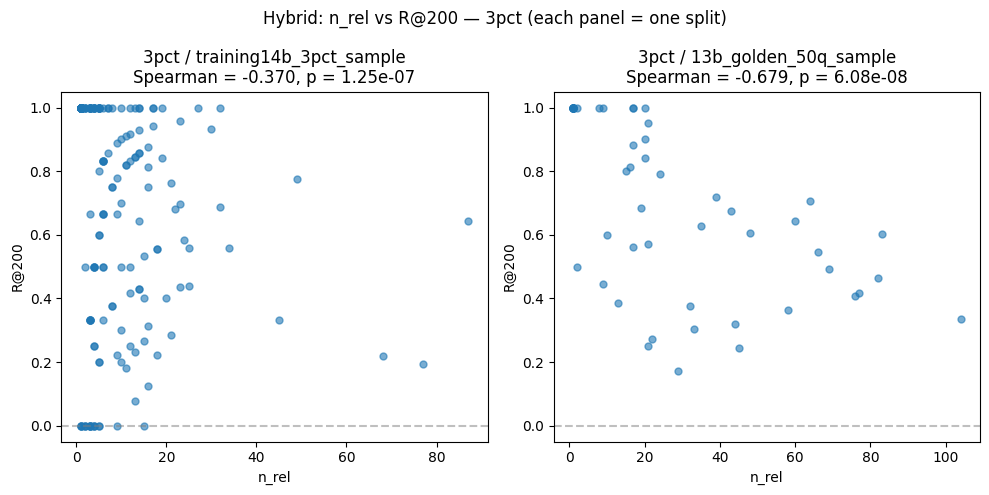

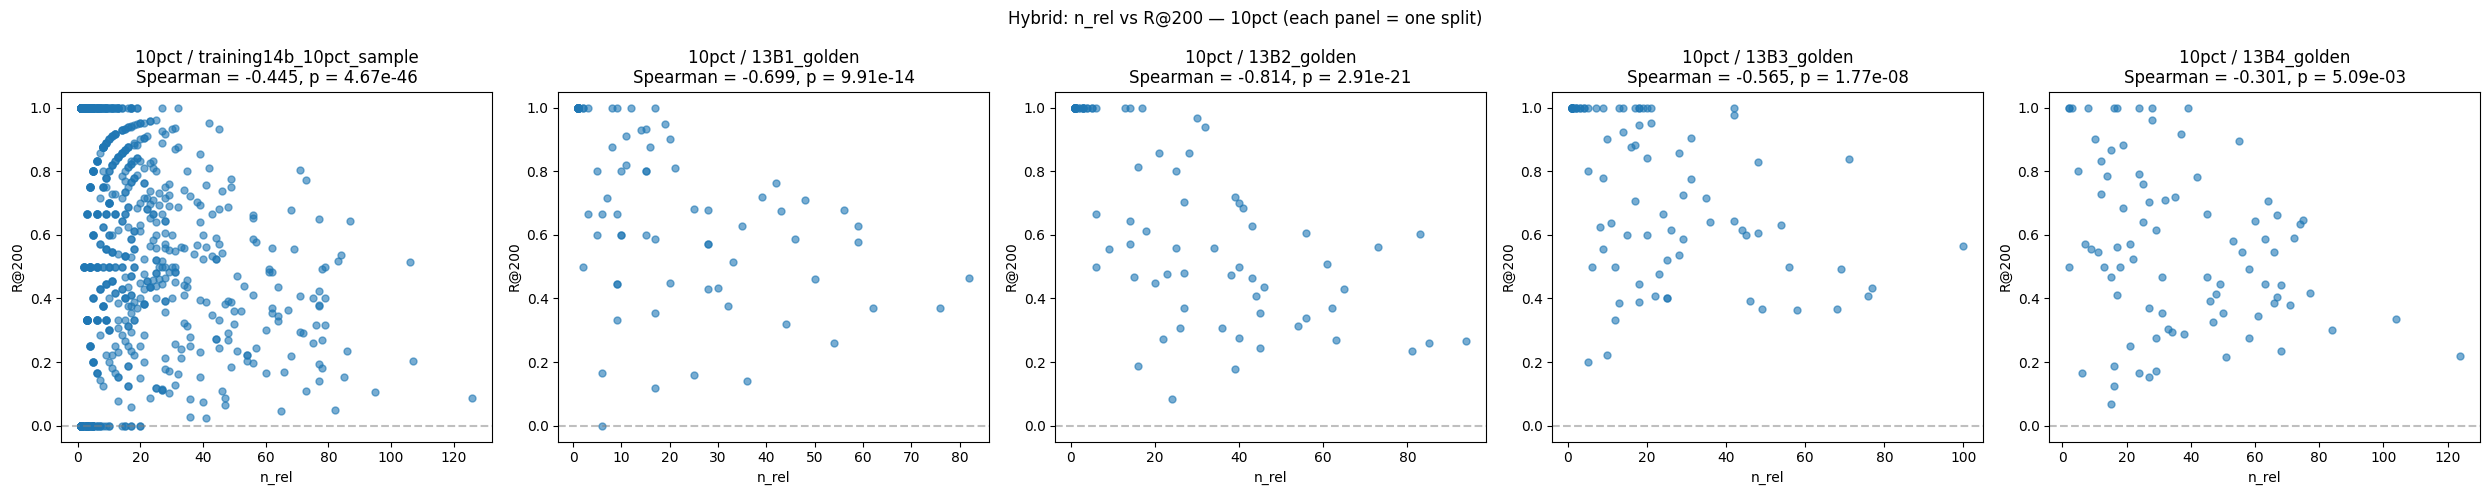

In [41]:
df = hybrid_per_query.copy()
df["n_rel"] = df.apply(_n_rel_lookup, axis=1)
df_clean = df.dropna(subset=["n_rel", "R@200"])

# Spearman per (dataset, split) only — no merging
for ds, sp in ANALYSIS_GROUPS:
    sub = df_clean[(df_clean["dataset"] == ds) & (df_clean["split"] == sp)]
    if len(sub) > 2:
        rho, pval = spearmanr(sub["n_rel"], sub["R@200"])
        print(f"{ds} / {sp}: Spearman = {rho:.4f}, p = {pval:.4e}")
print()

# Two separate figures: one for 3pct, one for 10pct (each with one subplot per split)
for name in SELECTED_DATASETS:
    groups = [(ds, sp) for ds, sp in ANALYSIS_GROUPS if ds == name]
    if not groups:
        continue
    n = len(groups)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (ds, sp) in zip(axes, groups):
        sub = df_clean[(df_clean["dataset"] == ds) & (df_clean["split"] == sp)]
        if sub.empty:
            ax.set_visible(False)
            continue
        rho_s, p_s = spearmanr(sub["n_rel"], sub["R@200"]) if len(sub) > 2 else (np.nan, np.nan)
        ax.scatter(sub["n_rel"], sub["R@200"], alpha=0.6, s=25)
        ax.set_xlabel("n_rel")
        ax.set_ylabel("R@200")
        ax.set_title(f"{ds} / {sp}\nSpearman = {rho_s:.3f}, p = {p_s:.2e}")
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    plt.suptitle(f"Hybrid: n_rel vs R@200 — {name} (each panel = one split)")
    plt.tight_layout()
    plt.show()

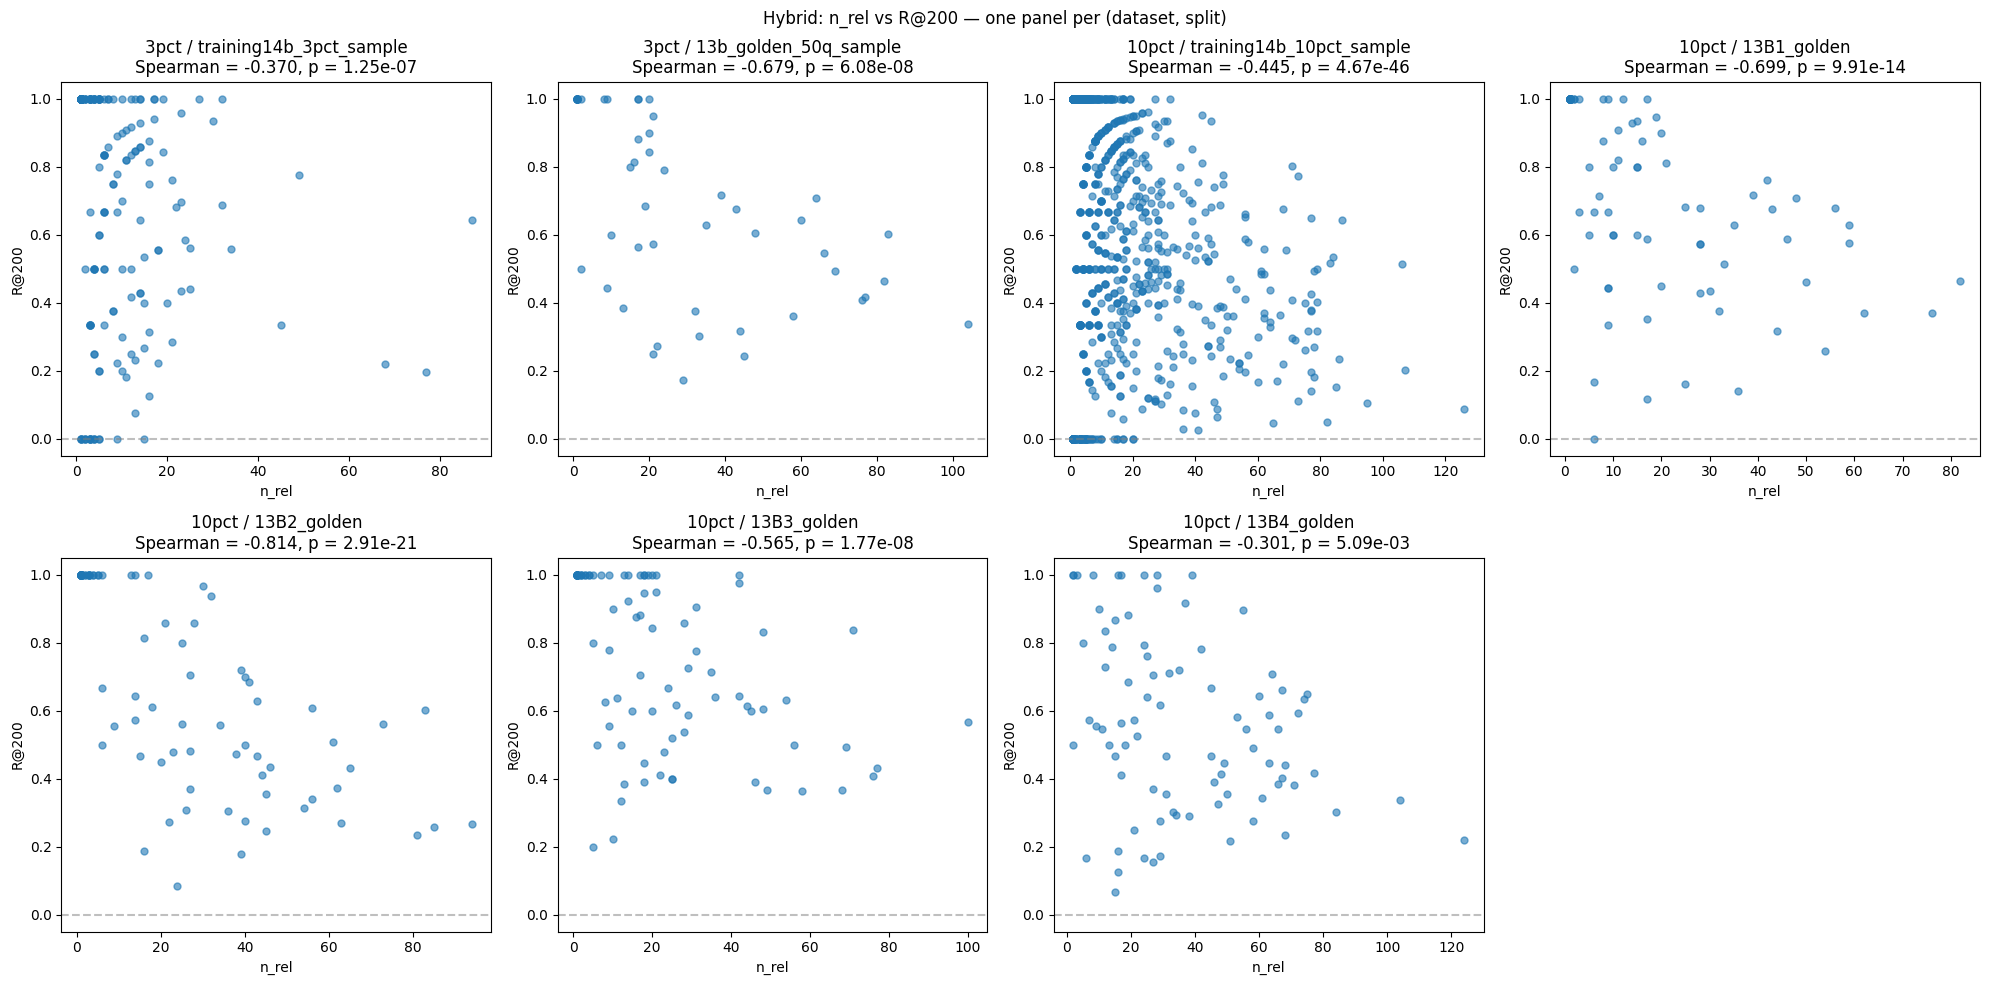

In [42]:
# Optional: one subplot per (dataset, split) — all splits visible, no merging
n = len(ANALYSIS_GROUPS)
ncol = min(n, 4)
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow))
if n == 1:
    axes = np.array([axes])
axes = axes.flatten()
for i, (ds, sp) in enumerate(ANALYSIS_GROUPS):
    ax = axes[i]
    sub = df_clean[(df_clean["dataset"] == ds) & (df_clean["split"] == sp)]
    if sub.empty:
        ax.set_visible(False)
        continue
    rho_s, p_s = spearmanr(sub["n_rel"], sub["R@200"]) if len(sub) > 2 else (np.nan, np.nan)
    ax.scatter(sub["n_rel"], sub["R@200"], alpha=0.6, s=25)
    ax.set_xlabel("n_rel")
    ax.set_ylabel("R@200")
    ax.set_title(f"{ds} / {sp}\nSpearman = {rho_s:.3f}, p = {p_s:.2e}")
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Hybrid: n_rel vs R@200 — one panel per (dataset, split)")
plt.tight_layout()
plt.show()

---
## 2.2 Bin-and-plot: n_rel vs R@200

Bin `n_rel` and plot **median** and **IQR** of R@200 per bin. Bins: 1–5, 6–10, 11–20, 21–40, 41–80, 81+.

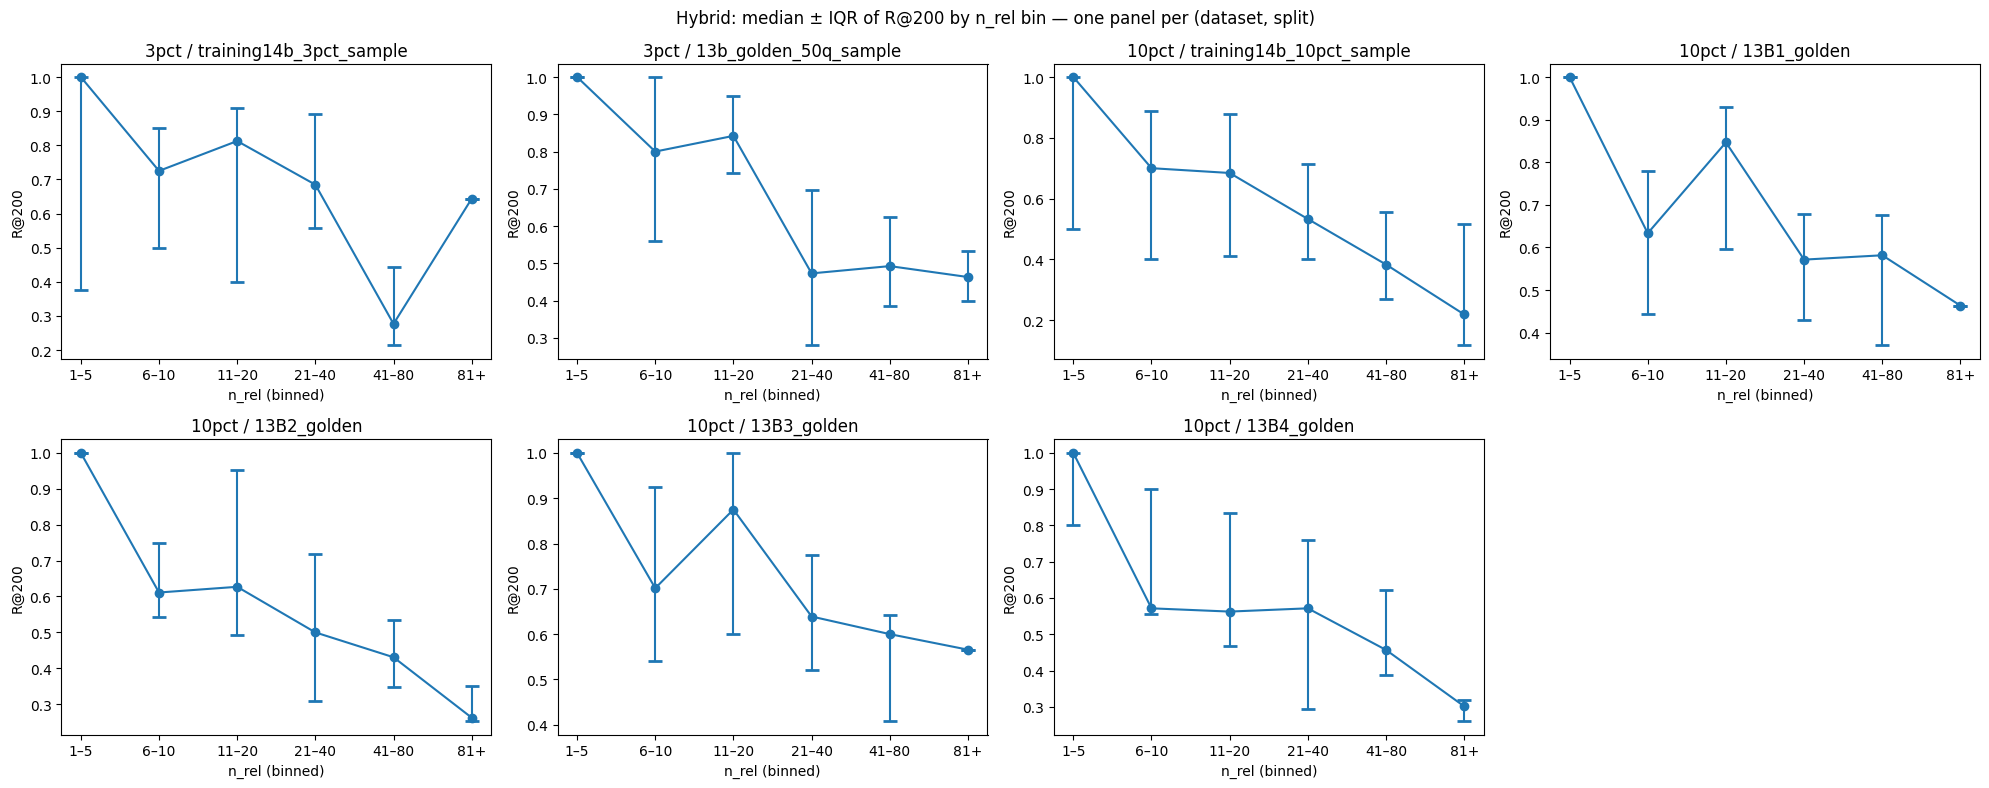

In [43]:
# Bins: (low, high] for 1–5, 6–10, 11–20, 21–40, 41–80, 81+
bin_edges = [0, 5, 10, 20, 40, 80, np.inf]
bin_labels = ["1–5", "6–10", "11–20", "21–40", "41–80", "81+"]

df_bin = df_clean.copy()
df_bin["n_rel_bin"] = pd.cut(df_bin["n_rel"], bins=bin_edges, labels=bin_labels)

# One subplot per (dataset, split) — each line plot is for one split only
n = len(ANALYSIS_GROUPS)
ncol = min(n, 4)
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow))
if n == 1:
    axes = np.array([axes])
axes = axes.flatten()
for i, (ds, sp) in enumerate(ANALYSIS_GROUPS):
    ax = axes[i]
    sub = df_bin[(df_bin["dataset"] == ds) & (df_bin["split"] == sp)]
    if sub.empty:
        ax.set_visible(False)
        continue
    agg = (
        sub.groupby("n_rel_bin", observed=True)["R@200"]
        .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
        .reset_index()
    )
    agg["iqr_lo"] = agg["median"] - agg["q25"]
    agg["iqr_hi"] = agg["q75"] - agg["median"]
    x = np.arange(len(agg))
    ax.errorbar(x, agg["median"], yerr=[agg["iqr_lo"].values, agg["iqr_hi"].values], fmt="o-", capsize=5, capthick=2)
    ax.set_xticks(x)
    ax.set_xticklabels(agg["n_rel_bin"])
    ax.set_xlabel("n_rel (binned)")
    ax.set_ylabel("R@200")
    ax.set_title(f"{ds} / {sp}")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Hybrid: median ± IQR of R@200 by n_rel bin — one panel per (dataset, split)")
plt.tight_layout()
plt.show()

---
## 3. Delta AP@10 vs n_rel

**Question:** Does reranking help less (or hurt) when n_rel is large?

- **delta_AP@10** = AP@10(BGE512 reranker) − AP@10(Hybrid) per query.
- **Plot:** x = n_rel (log scale), y = delta_AP@10; one panel per (dataset, split).
- **Binned summary:** Same bins (1–5, 6–10, 11–20, 21–40, 41–80, 81+). Per bin: median delta_AP@10, IQR, and **% queries improved** (delta > 0).

**Interpretation:**
- If **median delta_AP@10 drops with n_rel** (or becomes negative in high–n_rel bins) → MAP@10 ceiling is likely limited by "broad/many-gold" questions; reranker can't separate well / labels are diffuse.
- If **median delta_AP@10 is flat across bins** → n_rel is not the main driver; consider other factors (e.g. label noise, reranker promoting non-gold, evidence location).

Delta AP@10 table shape: (1505, 7)


,qid,AP@10_rerank,split,dataset,AP@10_hybrid,delta_AP10,n_rel
0,514a11add24251bc05000054,0.014286,training14b_3pct_sample,3pct,0.128571,-0.114286,21
1,514a1469d24251bc05000056,0.010000,training14b_3pct_sample,3pct,0.055556,-0.045556,18
2,5156be04d24251bc05000085,0.000000,training14b_3pct_sample,3pct,0.000000,0.000000,13
3,51585b28d24251bc0500008d,0.000000,training14b_3pct_sample,3pct,0.000000,0.000000,68
4,515c4f1f298dcd4e51000007,0.532407,training14b_3pct_sample,3pct,0.194444,0.337963,6
5,515dbb3b298dcd4e51000018,0.050000,training14b_3pct_sample,3pct,0.194167,-0.144167,77
6,51603912298dcd4e5100003b,0.040000,training14b_3pct_sample,3pct,0.000000,0.040000,5
7,517138d98ed59a060a000003,0.073333,training14b_3pct_sample,3pct,0.157857,-0.084524,16
8,5173bdb38ed59a060a000020,0.048571,training14b_3pct_sample,3pct,0.221944,-0.173373,87
9,517404878ed59a060a000023,0.000000,training14b_3pct_sample,3pct,0.000000,0.000000,16


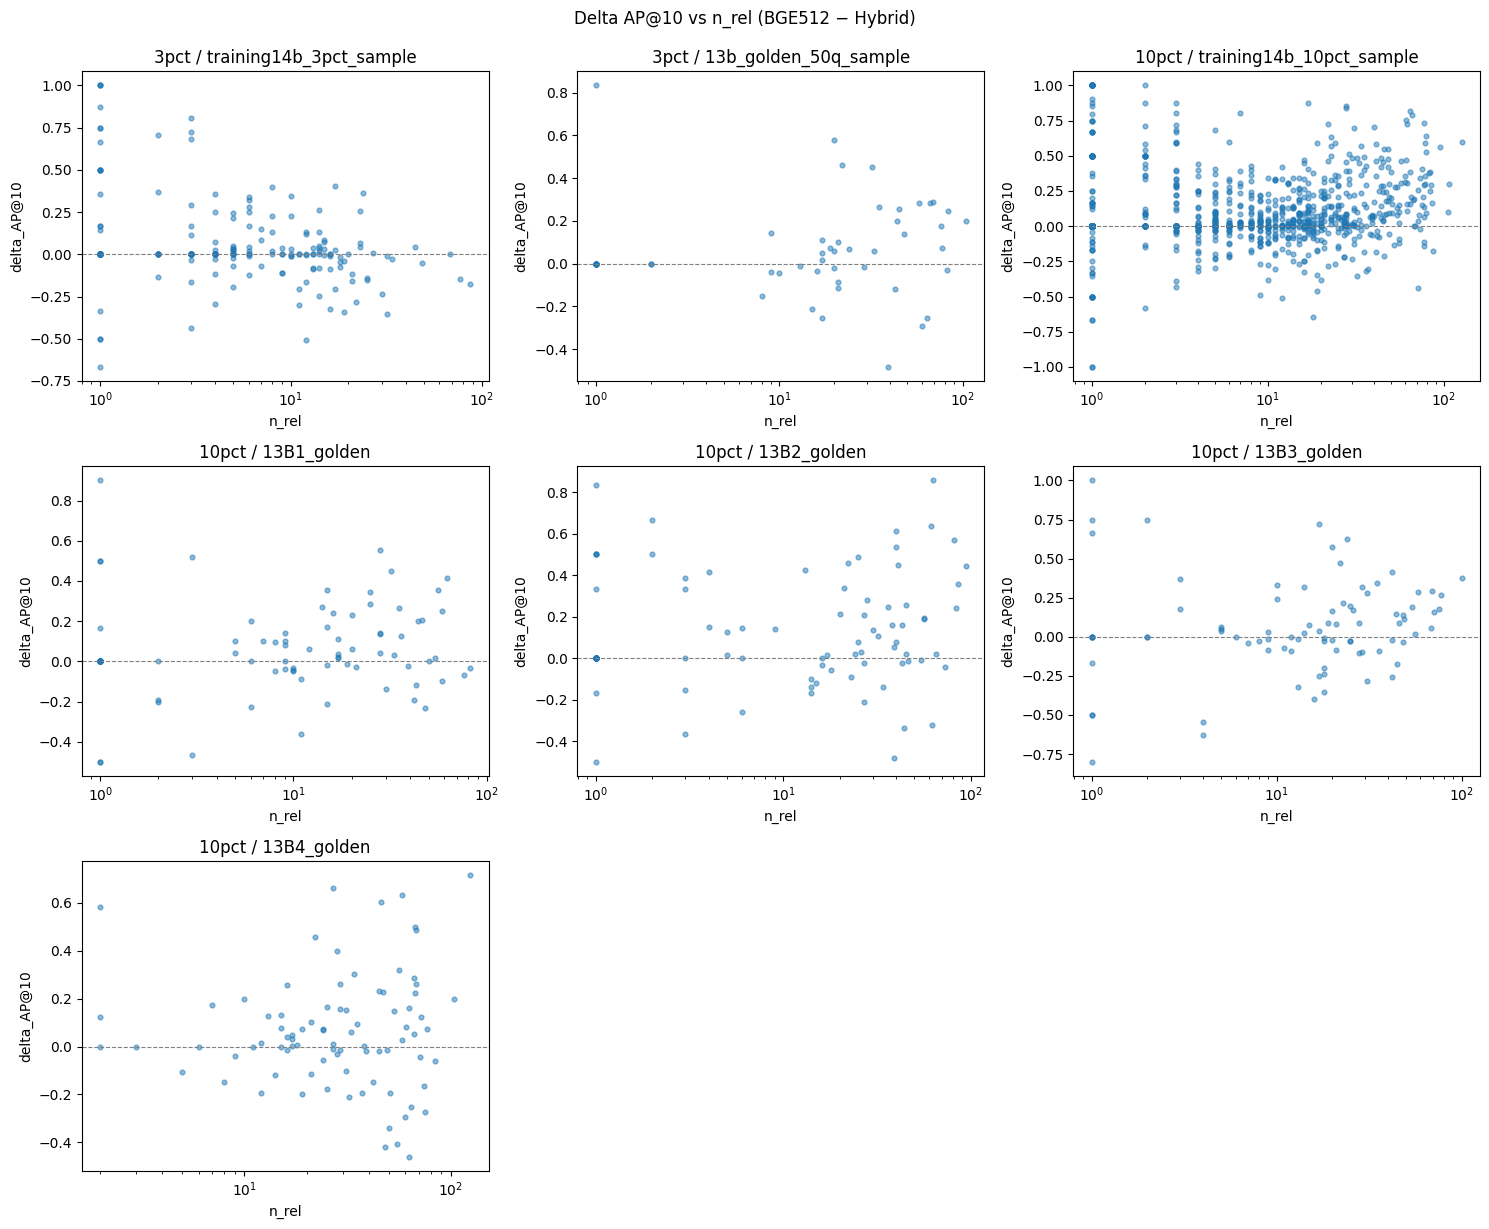

Binned summary: median delta_AP@10, IQR, % queries improved (delta > 0)


,dataset,split,n_rel_bin,median_delta,iqr_delta,n_queries,pct_improved
0,10pct,13B1_golden,1–5,0.000000,0.000000,29,24.137931
1,10pct,13B1_golden,6–10,0.000000,0.140516,14,42.857143
2,10pct,13B1_golden,11–20,0.049286,0.197778,16,68.750000
3,10pct,13B1_golden,21–40,0.137778,0.256111,13,76.923077
4,10pct,13B1_golden,41–80,0.008929,0.319692,12,58.333333
5,10pct,13B1_golden,81+,-0.030952,0.000000,1,0.000000
6,10pct,13B2_golden,1–5,0.000000,0.361111,31,41.935484
7,10pct,13B2_golden,6–10,0.070602,0.203026,4,75.000000
8,10pct,13B2_golden,11–20,-0.044167,0.127738,10,30.000000
9,10pct,13B2_golden,21–40,0.105556,0.261984,21,76.190476


In [44]:
# Load rerank (BGE512) per-query AP@10 for each (dataset, split)
rerank_per_query_dfs = []
for name in SELECTED_DATASETS:
    cfg = DATASET_CONFIG[name]
    rerank_dir = cfg["workflow_dir"] / "rerank" / "per_query"
    for split in cfg["splits"]:
        path = rerank_dir / f"best_rrf_{split}_top5000.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        if "qid" not in df.columns or "AP@10" not in df.columns:
            print(f"Missing qid/AP@10 in {path}")
            continue
        df = df[["qid", "AP@10"]].copy()
        df["qid"] = df["qid"].astype(str)
        df["split"] = split
        df["dataset"] = name
        df = df.rename(columns={"AP@10": "AP@10_rerank"})
        rerank_per_query_dfs.append(df)
rerank_ap = pd.concat(rerank_per_query_dfs, ignore_index=True)

# Merge hybrid (AP@10) + rerank (AP@10_rerank); add n_rel and delta_AP@10
hybrid_ap = hybrid_per_query[["dataset", "split", "qid", "AP@10"]].copy()
hybrid_ap = hybrid_ap.rename(columns={"AP@10": "AP@10_hybrid"})
delta_df = rerank_ap.merge(hybrid_ap, on=["dataset", "split", "qid"], how="inner")
delta_df["delta_AP10"] = delta_df["AP@10_rerank"] - delta_df["AP@10_hybrid"]

def _get_n_rel(dataset: str, split: str, qid: str) -> float:
    return n_rel_by_dataset.get(dataset, {}).get(split, {}).get(qid, np.nan)
delta_df["n_rel"] = delta_df.apply(lambda r: _get_n_rel(r["dataset"], r["split"], r["qid"]), axis=1)
delta_df = delta_df.dropna(subset=["n_rel"]).copy()
print("Delta AP@10 table shape:", delta_df.shape)
display(delta_df.head(10))

# Scatter: n_rel (log) vs delta_AP@10, one panel per (dataset, split)
bin_edges = [0, 5, 10, 20, 40, 80, np.inf]
bin_labels = ["1–5", "6–10", "11–20", "21–40", "41–80", "81+"]

groups = delta_df.groupby(["dataset", "split"], sort=False)
n_panels = len(groups)
n_cols = min(3, n_panels)
n_rows = (n_panels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_panels == 1:
    axes = np.array([axes])
axes = axes.flat
for ax, ((dataset, split), grp) in zip(axes, groups):
    ax.scatter(grp["n_rel"], grp["delta_AP10"], alpha=0.5, s=12)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("n_rel")
    ax.set_ylabel("delta_AP@10")
    ax.set_title(f"{dataset} / {split}")
for j in range(len(groups), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.suptitle("Delta AP@10 vs n_rel (BGE512 − Hybrid)", y=1.02)
plt.show()

# Binned summary: median delta_AP@10, IQR, % queries improved (delta > 0)
delta_df["n_rel_bin"] = pd.cut(delta_df["n_rel"], bins=bin_edges, labels=bin_labels)
binned = delta_df.groupby(["dataset", "split", "n_rel_bin"], observed=True).agg(
    median_delta=("delta_AP10", "median"),
    iqr_delta=("delta_AP10", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    n_queries=("delta_AP10", "count"),
    pct_improved=("delta_AP10", lambda s: (s > 0).mean() * 100),
).reset_index()
print("Binned summary: median delta_AP@10, IQR, % queries improved (delta > 0)")
display(binned)

takeaway:

Hybrid: larger n_rel → lower R@200 (denominator effect + broad queries).

Reranking (BGE512): tends to help more when n_rel is moderate/large, but is less reliable for small n_rel (≤10).

---
## 4. Regression audit for small n_rel

**Goal:** Controlled comparison of where the reranker regresses when n_rel is small.

**Filter:**
- n_rel ≤ 10  
- delta_AP@10 < 0 (BGE512 worse than Hybrid)  
- hybrid recall@2000 > 0 (gold is present; not a ceiling issue)

**Table columns:** qid, n_rel, query | hybrid_AP@10, bge_AP@10, delta_AP@10 | hybrid_hits@10, bge_hits@10 | first_gold_rank_hybrid, first_gold_rank_bge

**How to read the table:**
- **Gold pushed out of top-10:** `hybrid_hits@10 > bge_hits@10` and `first_gold_rank_bge > 10` → reranker mis-scoring or truncation/input issue.
- **Gold stayed in top-10 but AP dropped:** same hits@10 but lower AP → reranker changed ordering; likely label noise / near-duplicates.
- Use this to decide whether to focus on **reranker input** (evidence/truncation) vs **accept noise** (ensemble/guard-rail).

In [46]:
def hits_at_10_and_first_gold_rank(docs: list, rels: set) -> tuple:
    """Returns (hits@10, first_gold_rank). first_gold_rank is 1-based or np.nan if no gold in list."""
    if not rels:
        return 0, np.nan
    top10 = docs[:10]
    hits_at_10 = len(set(top10) & rels)
    for i, doc in enumerate(docs, start=1):
        if doc in rels:
            return hits_at_10, float(i)
    return hits_at_10, np.nan


# Filter: n_rel <= 10, delta_AP@10 < 0, and hybrid has gold in top 2000 (R@2000 > 0)
hybrid_r2000 = hybrid_per_query[["dataset", "split", "qid", "R@2000"]].copy()
regress_candidates = delta_df.merge(hybrid_r2000, on=["dataset", "split", "qid"], how="inner")
regress_filter = (
    (regress_candidates["n_rel"] <= 10)
    & (regress_candidates["delta_AP10"] < 0)
    & (regress_candidates["R@2000"] > 0)
)
regress_qids = regress_candidates.loc[regress_filter, ["dataset", "split", "qid"]].drop_duplicates()
print(f"Regression audit: {len(regress_qids)} queries (n_rel≤10, delta_AP@10<0, hybrid R@2000>0)")

# For each (dataset, split) load hybrid and rerank runs; compute hits@10 and first_gold_rank for audit qids
hybrid_hits, hybrid_first = {}, {}
bge_hits, bge_first = {}, {}
run_template = "best_rrf_{split}_top5000.tsv"

for name in SELECTED_DATASETS:
    cfg = DATASET_CONFIG[name]
    qrels = qrels_by_dataset[name]
    subset = regress_qids[regress_qids["dataset"] == name]
    if subset.empty:
        continue
    for split in subset["split"].unique():
        qids_in_split = subset[subset["split"] == split]["qid"].tolist()
        if not qids_in_split:
            continue
        # qrels: dict split -> dict qid -> set of docids
        split_qrels = qrels.get(split, {})
        # Hybrid run
        h_path = cfg["workflow_dir"] / "hybrid" / "runs" / run_template.format(split=split)
        if h_path.exists():
            h_df = load_run(h_path)
            qid_col, doc_col = h_df.columns.tolist()
            for qid in qids_in_split:
                grp = h_df[h_df[qid_col] == qid]
                if grp.empty:
                    continue
                docs = grp[doc_col].tolist()
                rels = split_qrels.get(qid, set())
                hh, hf = hits_at_10_and_first_gold_rank(docs, rels)
                hybrid_hits[(name, split, qid)] = hh
                hybrid_first[(name, split, qid)] = hf
        # Rerank (BGE) run
        r_path = cfg["workflow_dir"] / "rerank" / "runs" / run_template.format(split=split)
        if r_path.exists():
            r_df = load_run(r_path)
            qid_col, doc_col = r_df.columns.tolist()
            for qid in qids_in_split:
                grp = r_df[r_df[qid_col] == qid]
                if grp.empty:
                    continue
                docs = grp[doc_col].tolist()
                rels = split_qrels.get(qid, set())
                bh, bf = hits_at_10_and_first_gold_rank(docs, rels)
                bge_hits[(name, split, qid)] = bh
                bge_first[(name, split, qid)] = bf

# Build audit table
base = regress_candidates.loc[regress_filter, ["dataset", "split", "qid", "n_rel", "AP@10_hybrid", "AP@10_rerank", "delta_AP10"]].drop_duplicates()
base = base.rename(columns={"AP@10_hybrid": "hybrid_AP@10", "AP@10_rerank": "bge_AP@10", "delta_AP10": "delta_AP@10"})
base["hybrid_hits@10"] = base.apply(lambda r: hybrid_hits.get((r["dataset"], r["split"], r["qid"]), np.nan), axis=1)
base["bge_hits@10"] = base.apply(lambda r: bge_hits.get((r["dataset"], r["split"], r["qid"]), np.nan), axis=1)
base["first_gold_rank_hybrid"] = base.apply(lambda r: hybrid_first.get((r["dataset"], r["split"], r["qid"]), np.nan), axis=1)
base["first_gold_rank_bge"] = base.apply(lambda r: bge_first.get((r["dataset"], r["split"], r["qid"]), np.nan), axis=1)
base["query"] = base.apply(lambda r: question_text_by_dataset.get(r["dataset"], {}).get(r["split"], {}).get(r["qid"], ""), axis=1)

cols_order = [
    "dataset", "split", "qid", "n_rel", "query",
    "hybrid_AP@10", "bge_AP@10", "delta_AP@10",
    "hybrid_hits@10", "bge_hits@10",
    "first_gold_rank_hybrid", "first_gold_rank_bge",
]
audit_table = base[[c for c in cols_order if c in base.columns]]
print("Regression audit table (small n_rel, delta_AP@10 < 0, hybrid R@2000 > 0):")
display(audit_table)

Regression audit: 163 queries (n_rel≤10, delta_AP@10<0, hybrid R@2000>0)
Regression audit table (small n_rel, delta_AP@10 < 0, hybrid R@2000 > 0):


,dataset,split,qid,n_rel,query,hybrid_AP@10,bge_AP@10,delta_AP@10,hybrid_hits@10,bge_hits@10,first_gold_rank_hybrid,first_gold_rank_bge
16,3pct,training14b_3pct_sample,530cefaaad0bf1360c000008,10,Is lambrolizumab effective for treatment of pa...,0.128571,0.116667,-0.011905,2,2,1.0,2.0
35,3pct,training14b_3pct_sample,54ede8c594afd61504000009,5,In which phase of the cell cycle arrest is imp...,0.500000,0.433333,-0.066667,3,3,1.0,1.0
41,3pct,training14b_3pct_sample,552fa32fbc4f83e828000001,3,Is CD56 useful in Ewing sarcoma prognosis?,0.666667,0.500000,-0.166667,2,2,1.0,1.0
53,3pct,training14b_3pct_sample,56e2cec751531f7e33000015,9,What is the structural fold of bromodomain pro...,0.259259,0.148148,-0.111111,3,2,1.0,1.0
69,3pct,training14b_3pct_sample,58a1da4e78275d0c4a000059,9,Has small pox been eradicated from the world?,0.111111,0.000000,-0.111111,1,0,1.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1399,10pct,13B3_golden,67fbe25118b1e36f2e000115,9,Is obesity a familial syndrome?,0.012346,0.000000,-0.012346,1,0,9.0,15.0
1412,10pct,13B3_golden,67fce38c18b1e36f2e000135,9,What are the glioblastoma stem cell (GSC) stat...,0.226852,0.142857,-0.083995,3,2,1.0,1.0
1464,10pct,13B4_golden,67fc546c18b1e36f2e000130,8,Has Antibiotic use induced hiccups?,0.550000,0.400000,-0.150000,3,2,1.0,1.0
1492,10pct,13B4_golden,680f4ae9353a4a2e6b000009,9,Is Electroconvulsive Therapy used for any type...,0.081481,0.043651,-0.037831,2,2,3.0,7.0


In [47]:
# Summary metrics for small-n_rel regressions (coverage, loss, gain) and save audit table

# Ensure we have regress_candidates and regress_filter from the previous cell
assert "regress_candidates" in globals() and "regress_filter" in globals(), "Run the regression-audit cell first."

summary_rows = []

# Per (dataset, split)
for (dataset, split), group in regress_candidates.groupby(["dataset", "split"], sort=False):
    qids_all = group["qid"].unique()
    Q = len(qids_all)
    if Q == 0:
        continue
    mask_S = (
        (group["n_rel"] <= 10)
        & (group["delta_AP10"] < 0)
        & (group["R@2000"] > 0)
    )
    S_group = group[mask_S]
    qids_S = S_group["qid"].unique()
    cov = len(qids_S) / Q
    loss = (-S_group["delta_AP10"].sum()) / Q
    gain_total = group["delta_AP10"].sum() / Q
    loss_fraction = loss / gain_total if gain_total != 0 else np.nan
    summary_rows.append(
        {
            "dataset": dataset,
            "split": split,
            "Q": Q,
            "|S|": len(qids_S),
            "coverage": cov,
            "loss": loss,
            "gain_total": gain_total,
            "loss_fraction": loss_fraction,
        }
    )

# Overall (across all datasets/splits)
qids_all = regress_candidates["qid"].unique()
Q_all = len(qids_all)
mask_S_all = regress_filter
S_all = regress_candidates[mask_S_all]
qids_S_all = S_all["qid"].unique()
coverage_all = len(qids_S_all) / Q_all if Q_all > 0 else np.nan
loss_all = (-S_all["delta_AP10"].sum()) / Q_all if Q_all > 0 else np.nan
gain_total_all = regress_candidates["delta_AP10"].sum() / Q_all if Q_all > 0 else np.nan
loss_fraction_all = loss_all / gain_total_all if gain_total_all not in (0, np.nan) else np.nan
summary_rows.append(
    {
        "dataset": "ALL",
        "split": "ALL",
        "Q": Q_all,
        "|S|": len(qids_S_all),
        "coverage": coverage_all,
        "loss": loss_all,
        "gain_total": gain_total_all,
        "loss_fraction": loss_fraction_all,
    }
)

regression_summary = pd.DataFrame(summary_rows)
print("Small-n_rel regression summary (per split and overall):")
display(regression_summary)

# Save audit table to disk
analysis_dir = base_dir / "output" / "analysis_output"
analysis_dir.mkdir(parents=True, exist_ok=True)
audit_path = analysis_dir / "regression_audit_small_n_rel.csv"
audit_table.to_csv(audit_path, index=False)
print(f"Saved regression audit table to: {audit_path}")

Small-n_rel regression summary (per split and overall):


,dataset,split,Q,|S|,coverage,loss,gain_total,loss_fraction
0,3pct,training14b_3pct_sample,192,22,0.114583,0.020508,0.055907,0.366825
1,3pct,13b_golden_50q_sample,50,3,0.060000,0.004602,0.065147,0.070634
2,10pct,training14b_10pct_sample,923,109,0.118093,0.020095,0.105089,0.191215
3,10pct,13B1_golden,85,11,0.129412,0.027041,0.057917,0.466897
4,10pct,13B2_golden,85,5,0.058824,0.016989,0.125651,0.135207
5,10pct,13B3_golden,85,10,0.117647,0.038835,0.064378,0.603242
6,10pct,13B4_golden,85,3,0.035294,0.003465,0.063066,0.054937
7,ALL,ALL,923,125,0.135428,0.032560,0.148889,0.218687


Saved regression audit table to: /Users/yun/develop/BioASQ/output/analysis_output/regression_audit_small_n_rel.csv


In [48]:
# Failure-type breakdown within regression set S (Type A vs Type B)

# S is exactly the set of rows in audit_table
S_df = audit_table.copy()

rows = []
for split, grp in S_df.groupby("split", sort=False):
    n = len(grp)
    if n == 0:
        continue
    # Type A: gold pushed out of top-10 (hard failure)
    typeA = (grp["bge_hits@10"] < grp["hybrid_hits@10"]).mean() * 100
    # Type B: hits same, ordering worse (soft failure)
    typeB = ((grp["bge_hits@10"] == grp["hybrid_hits@10"]) & (grp["bge_AP@10"] < grp["hybrid_AP@10"])).mean() * 100
    rows.append({
        "split": split,
        "|S|": n,
        "pct_type_A": typeA,
        "pct_type_B": typeB,
    })

failure_breakdown = pd.DataFrame(rows)
print("Failure-type breakdown within regression set S (per split):")
display(failure_breakdown)

Failure-type breakdown within regression set S (per split):


,split,|S|,pct_type_A,pct_type_B
0,training14b_3pct_sample,22,50.000000,45.454545
1,13b_golden_50q_sample,3,66.666667,33.333333
2,training14b_10pct_sample,109,53.211009,40.366972
3,13B1_golden,11,45.454545,45.454545
4,13B2_golden,5,20.000000,80.000000
5,13B3_golden,10,40.000000,60.000000
6,13B4_golden,3,66.666667,33.333333


Next move (one step): Add a top-k guard rail for BGE

This is the cleanest way to reduce Type A without re-engineering models.

Guard-rail rule (very simple)

When producing the final top-10 from BGE, don’t rely purely on BGE scores. Instead:

Final top-10 =

top m docs by BGE512, plus

top 10−m docs by Hybrid (or BM25) that are not already included.

Start with m = 8 (so you keep 2 “anchors” from hybrid).